In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap

PATH_BioData = "../../../DATASETS/BioData_backup_alex/"

PATH_merge_df = "merged_dataset.csv"

PATH_save_IMGs = "../../../IMGS/df_analysis_2/PCA_UMAP_KMeans2/"

In [32]:
def load_embeddings_with_labels(embed_path, label_path, id_col="accession_code" , label_col="class"):
    df_embed = pd.read_csv(embed_path)
    df_embed[id_col] = df_embed['UniProt_ID']
    df_embed = df_embed.drop(columns=['UniProt_ID'])
    df_labels = pd.read_csv(label_path)

    print(f"Loaded {embed_path} with columns: {df_embed.columns.tolist()}")
    print(f"Loaded {label_path} with columns: {df_labels.columns.tolist()}")

    df_labels = df_labels[[id_col, label_col]]

    df = df_embed.merge(df_labels)

    # Fallback to catch either dim_0 or numbered columns like "0", "1", ...
    emb_cols = [col for col in df.columns if col.startswith("dim_") or col.isdigit()]
    if not emb_cols:
        raise ValueError(f"No embedding columns found in {embed_path}. Columns: {df.columns.tolist()}")

    df["embedding"] = df[emb_cols].apply(lambda row: row.values.astype(np.float32), axis=1)
    df = df.drop(columns=emb_cols)
    return df

In [33]:
import os
import re
from glob import glob

# Set your folder
geokg_folder = "../../../DATASETS/embeddings/GeOKG/2025-05-16/"
label_path = "../../../DATASETS/raw_data/uniprot_ids_labeled.csv"

# New pattern capturing everything including AE info
new_pattern = r"geokg_embeddings_(\d+)dim(?:_go_ae_IN_(\d+)dim_OUT_(\d+)dim)?_(mean_pool|padding)_(C_F|C_F_P)_go_terms\.csv"

# Find all .csv files matching GeOKG embedding format
files = glob(os.path.join(geokg_folder, "geokg_embeddings_*_go_terms.csv"))

print(f"Found {len(files)} files matching the new pattern.")

# Grouping: {(dim, strategy): {category: path}}
geokg_datasets = {}

for f in files:
    basename = os.path.basename(f)
    match = re.match(new_pattern, basename)

    if match:
        emb_dim, ae_in, ae_out, strategy, category = match.groups()
        key = (int(emb_dim), strategy)
        category = category.replace("CF", "C_F")  # unify naming
        if key not in geokg_datasets:
            geokg_datasets[key] = {}
        geokg_datasets[key][category] = f

# Now load the data for all category-grouped files
all_dfs_by_dim_strategy = {}

for f in files:
    basename = os.path.basename(f)
    match = re.match(new_pattern, basename)

    if match:
        emb_dim, ae_in, ae_out, strategy, category = match.groups()

        # Determine effective dimension:
        if ae_out:
            effective_dim = int(ae_out)
        else:
            effective_dim = int(emb_dim)

        key = (effective_dim, strategy)
        category = category.replace("CF", "C_F")  # normalize category label

        if key not in all_dfs_by_dim_strategy:
            all_dfs_by_dim_strategy[key] = {}

        # Load file only once per (dim, strategy, category)
        print(f"Loading: {basename}")
        df = load_embeddings_with_labels(os.path.join(geokg_folder, basename), PATH_merge_df, id_col="accession_code")
        all_dfs_by_dim_strategy[key][category] = df

print(f"\n✅ Loaded {len(all_dfs_by_dim_strategy)} grouped (dim, strategy) embedding sets.")


Found 115 files matching the new pattern.
Loading: geokg_embeddings_1000dim_mean_pool_C_F_go_terms.csv
Loaded ../../../DATASETS/embeddings/GeOKG/2025-05-16/geokg_embeddings_1000dim_mean_pool_C_F_go_terms.csv with columns: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126'

In [35]:
# Print the loaded datasets
for (dim, strategy), categories in all_dfs_by_dim_strategy.items():
    print(f"\nDim: {dim}, Strategy: {strategy}")
    for category, df in categories.items():
        print(f"  Category: {category}, Shape: {df.shape}, Columns: {df.columns.tolist()}")
        print(f" Embedding columns: {df['embedding'].apply(lambda x: len(x)).unique()}")


Dim: 1000, Strategy: mean_pool
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [1000]
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [1000]

Dim: 128, Strategy: mean_pool
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [128]
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [128]

Dim: 32, Strategy: mean_pool
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [32]
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [32]

Dim: 128, Strategy: padding
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [1280]
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedd

In [ ]:
def reduce_and_plot(method, dfs_dict, label_col="class", n_components=2, figsize=(15, 4), title=None, save_img=False):
    ordered_categories = ["C_F", "C_F_P"]
    fig, axes = plt.subplots(1, len(ordered_categories), figsize=figsize)

    if title:
        fig.suptitle(title, fontsize=16)

    for ax, name in zip(axes, ordered_categories):
        print(f"Processing {name}...")
        if name not in dfs_dict:
            ax.axis("off")
            ax.set_title(f"{name} (missing)")
            continue

        df = dfs_dict[name]
        embeddings = np.vstack(df["embedding"].to_numpy())
        labels = df[label_col].values

        # Validate embedding dimensions
        expected_dim = embeddings.shape[1]
        if embeddings.shape[1] != expected_dim:
            print(f"⚠️ Skipping {name} due to mismatched embedding dimensions: {embeddings.shape[1]} (expected {expected_dim})")
            ax.axis("off")
            ax.set_title(f"{name} (dim mismatch)")
            continue
        
        try:
            if method == "PCA":
                reducer = PCA(n_components=n_components)
            elif method == "UMAP":
                reducer = umap.UMAP(n_components=n_components, random_state=42)
            elif method == "KMeans2":
                reducer = KMeans(n_clusters=2, random_state=42)
                clusters = reducer.fit_predict(embeddings)
                ax.scatter(embeddings[:, 0], embeddings[:, 1], c=labels, cmap="coolwarm", alpha=0.6)
                ax.set_title(f"{name} (KMeans)")
                continue
            else:
                raise ValueError("Unsupported method")

            reduced = reducer.fit_transform(embeddings)
            ax.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="coolwarm", alpha=0.6)
            ax.set_title(f"{name} ({method})")
        except Exception as e:
            print(f"❌ Error processing {name}: {e}")
            ax.axis("off")
            ax.set_title(f"{name} (error)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save the figure
    if save_img:
        if not os.path.exists(PATH_save_IMGs):
            os.makedirs(PATH_save_IMGs)
                
        if title:
            plt.savefig(os.path.join(PATH_save_IMGs, f"{title.replace(' ', '_')}.png"), dpi=300)
        else:
            plt.savefig(os.path.join(PATH_save_IMGs, f"{method}.png"), dpi=300)

    plt.show()

In [ ]:
def plot_geokg_by_dim(all_dfs_by_dim, method="PCA", dims=[50, 100, 200, 500, 1000]):
    """
    Plot PCA, UMAP, or KMeans2 for GeOKG embeddings by dimension in a fixed order.

    Parameters:
        all_dfs_by_dim (dict): Dictionary {dimension: {category: DataFrame}}
        method (str): One of "PCA", "UMAP", "KMeans2"
        dims (list): Order of dimensions to display
    """
    for (dim, strategy), categories in all_dfs_by_dim.items():
        
        print(f"\nDim: {dim}, Strategy: {strategy}")
        for category, df in categories.items():
            print(f"  Category: {category}, Shape: {df.shape}, Columns: {df.columns.tolist()}")
            print(f" Embedding columns: {df['embedding'].apply(lambda x: len(x)).unique()}")

        # Reduce and plot
        reduce_and_plot(method, categories, label_col="class", 
                        title=f"{method} - Dim: {dim}, Strategy: {strategy}", 
                        save_title=f"{method}_{dim}_{strategy}", save_img=True)


Dim: 1000, Strategy: mean_pool
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [1000]
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [1000]
Processing C_F...
Processing C_F_P...


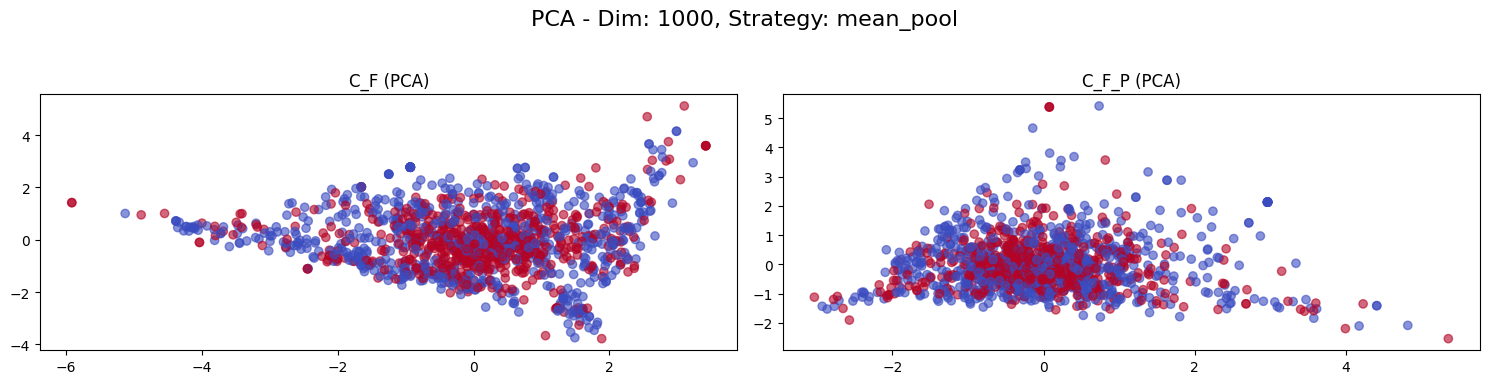


Dim: 128, Strategy: mean_pool
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [128]
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [128]
Processing C_F...
Processing C_F_P...


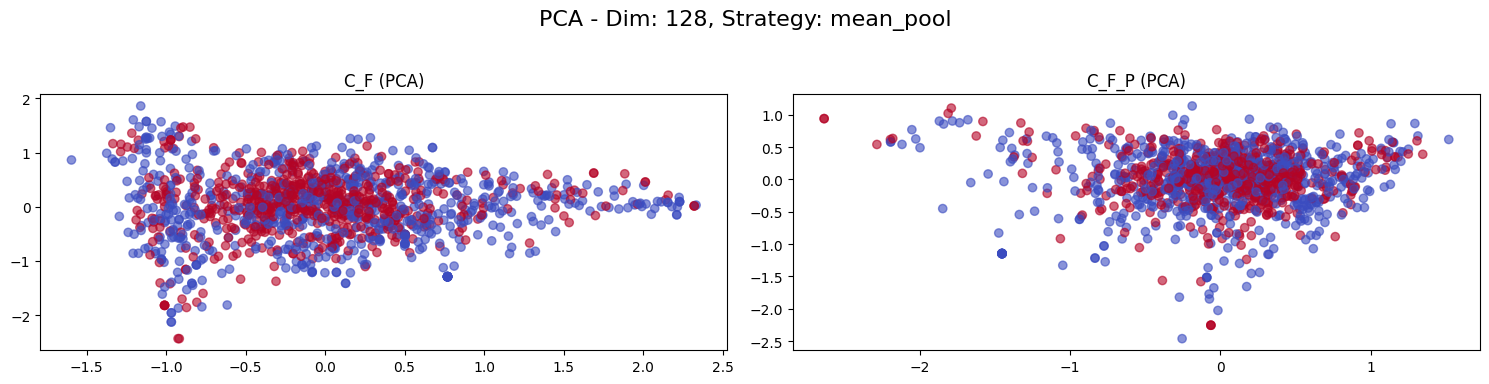


Dim: 32, Strategy: mean_pool
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [32]
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [32]
Processing C_F...
Processing C_F_P...


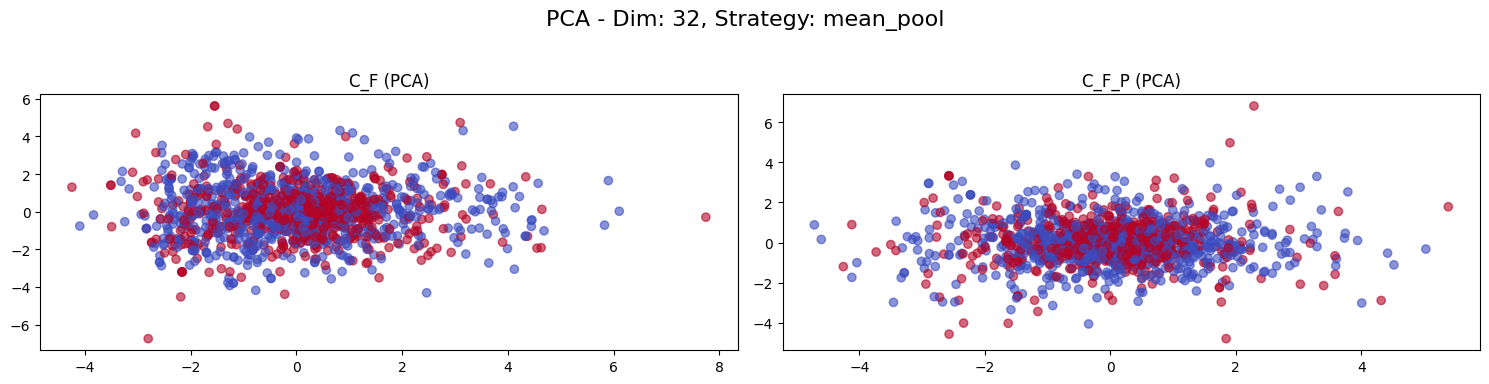


Dim: 128, Strategy: padding
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [1280]
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [1280]
Processing C_F...
Processing C_F_P...


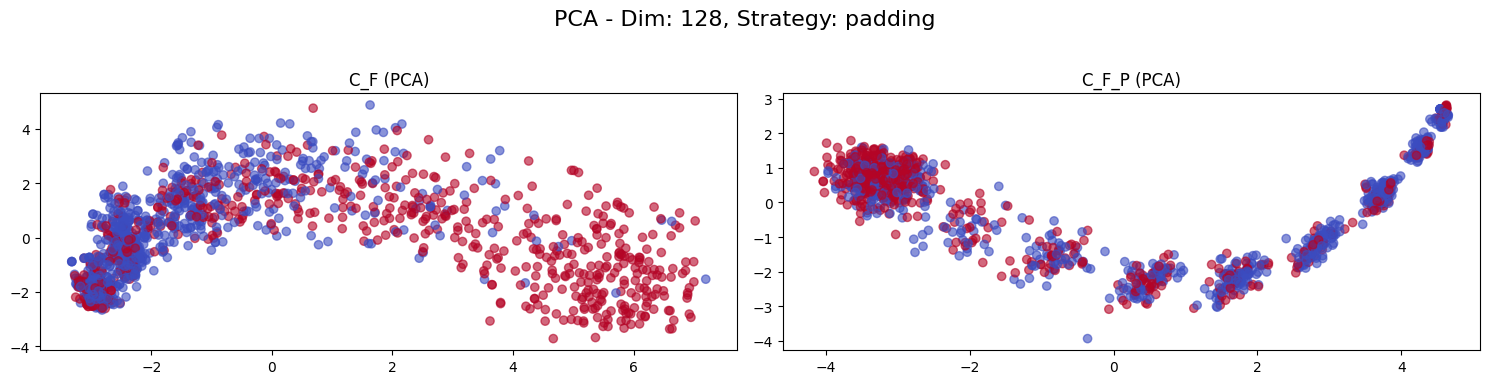


Dim: 500, Strategy: mean_pool
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [500]
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [500]
Processing C_F...
Processing C_F_P...


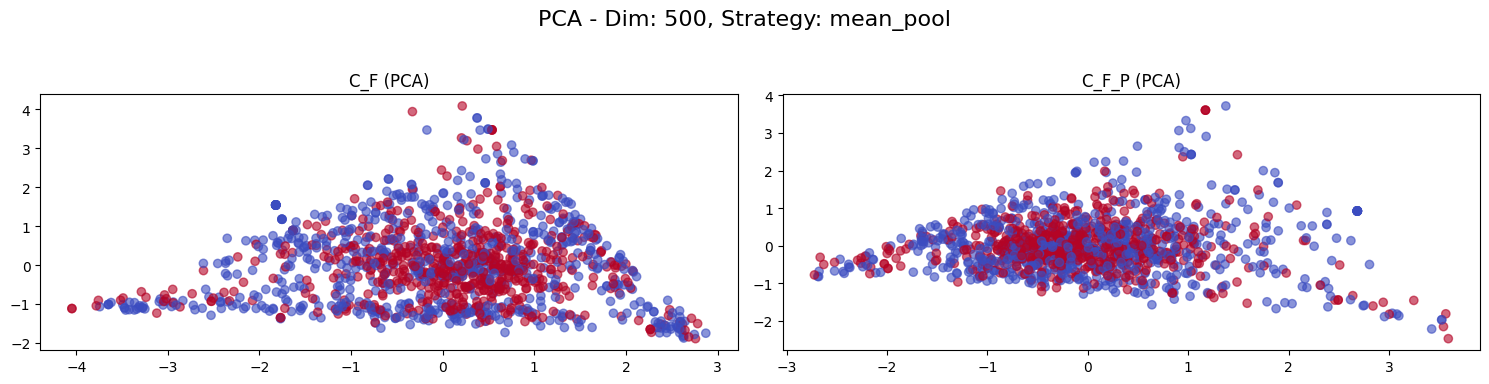


Dim: 100, Strategy: padding
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [1000]
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [1000]
Processing C_F...
Processing C_F_P...


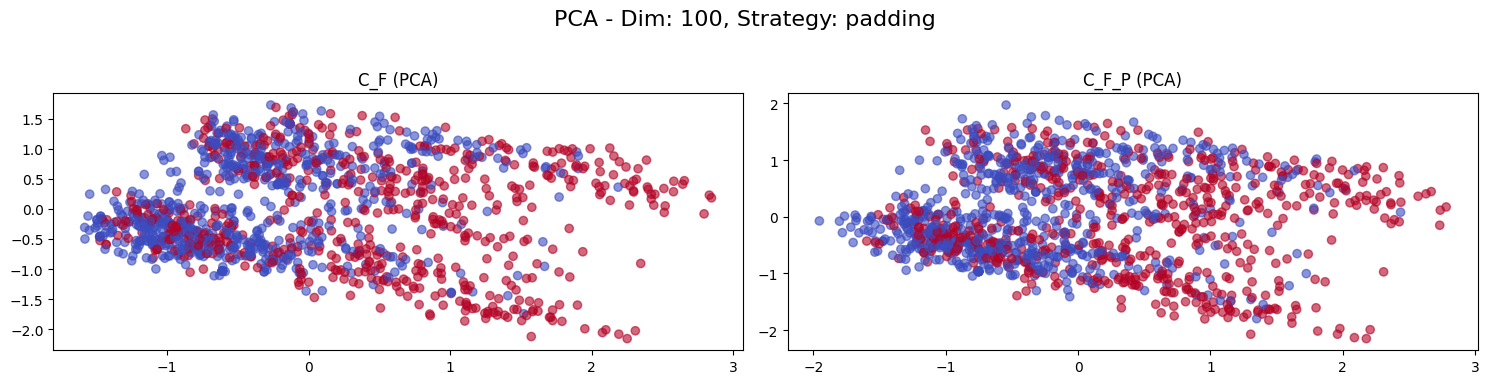


Dim: 200, Strategy: mean_pool
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [200]
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [200]
Processing C_F...
Processing C_F_P...


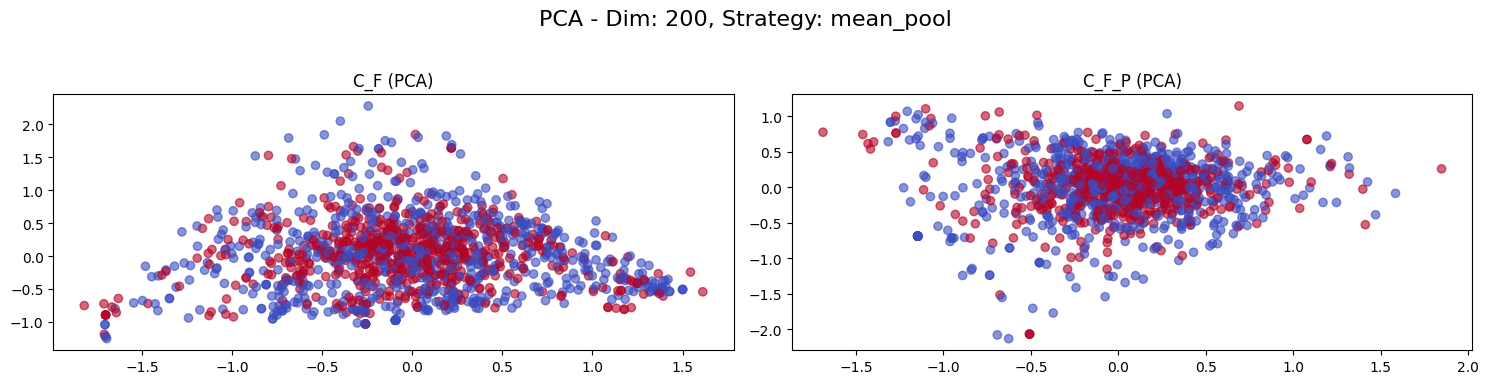


Dim: 64, Strategy: mean_pool
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [64]
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [64]
Processing C_F...
Processing C_F_P...


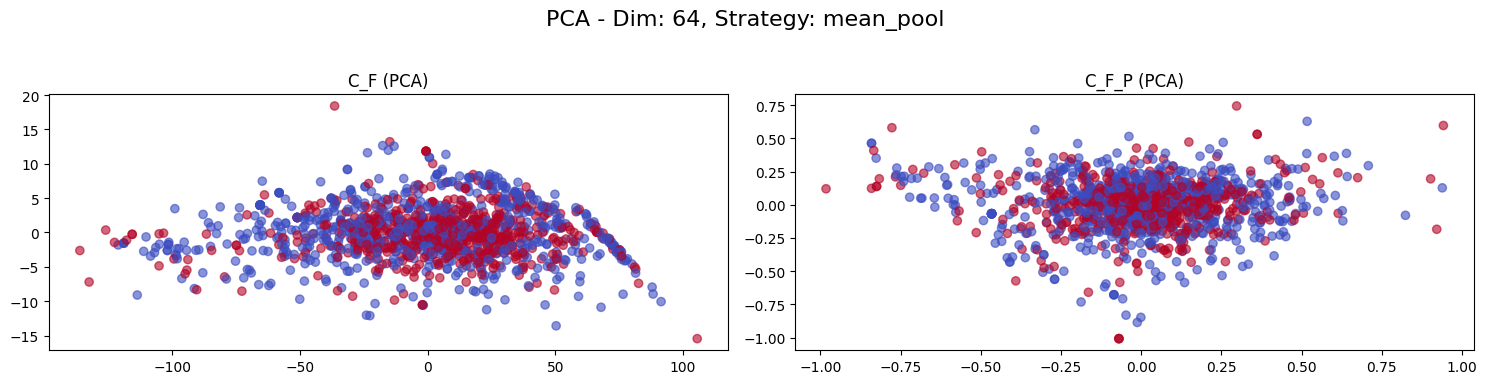


Dim: 32, Strategy: padding
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [320]
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [320]
Processing C_F...
Processing C_F_P...


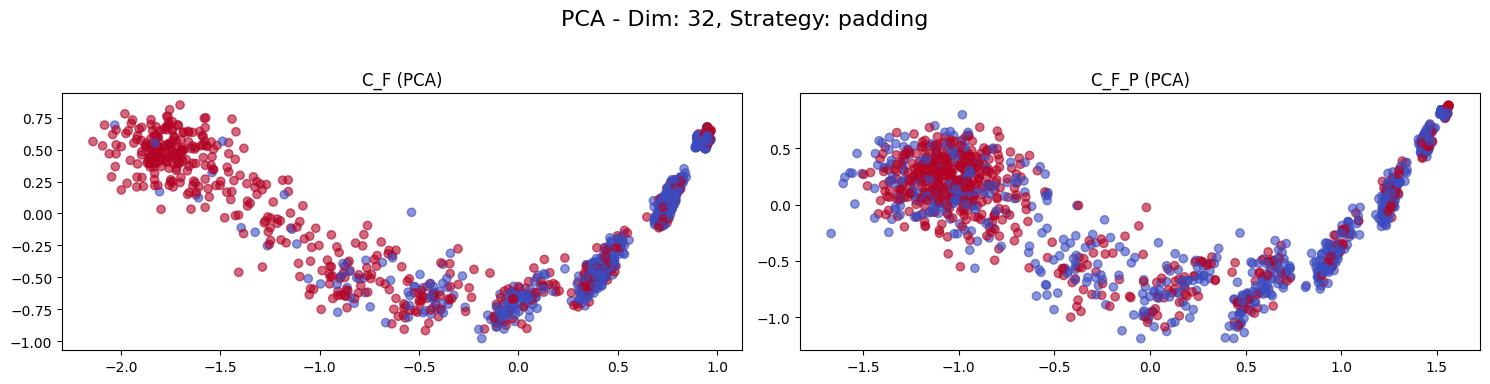


Dim: 100, Strategy: mean_pool
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [100]
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [100]
Processing C_F...
Processing C_F_P...


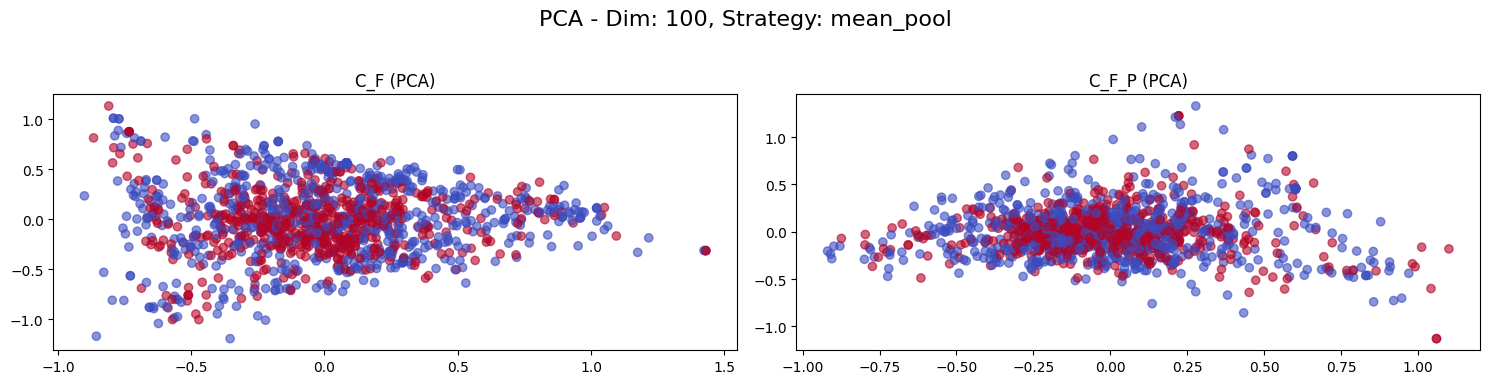


Dim: 64, Strategy: padding
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [640]
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [640]
Processing C_F...
Processing C_F_P...


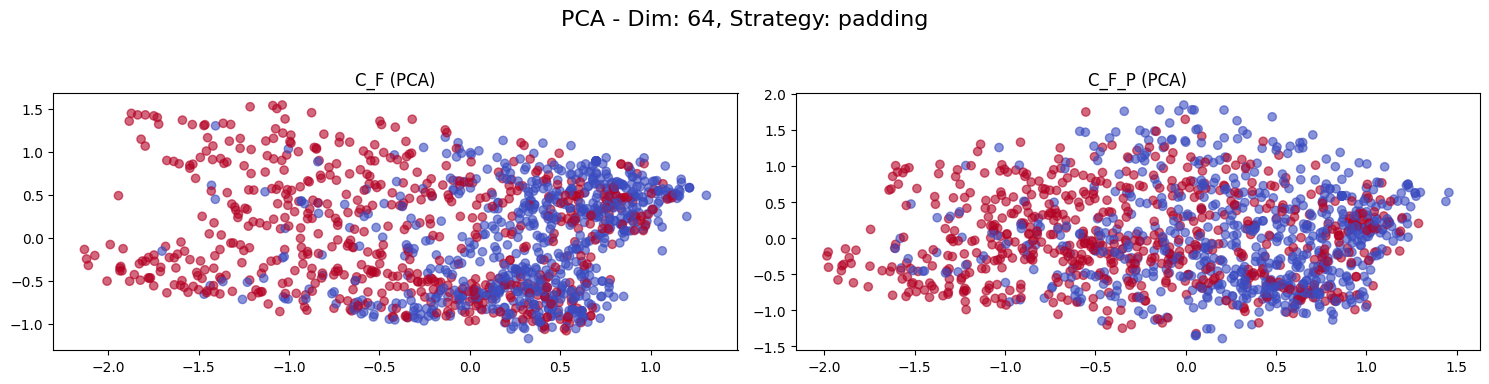


Dim: 50, Strategy: mean_pool
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [50]
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [50]
Processing C_F...
Processing C_F_P...


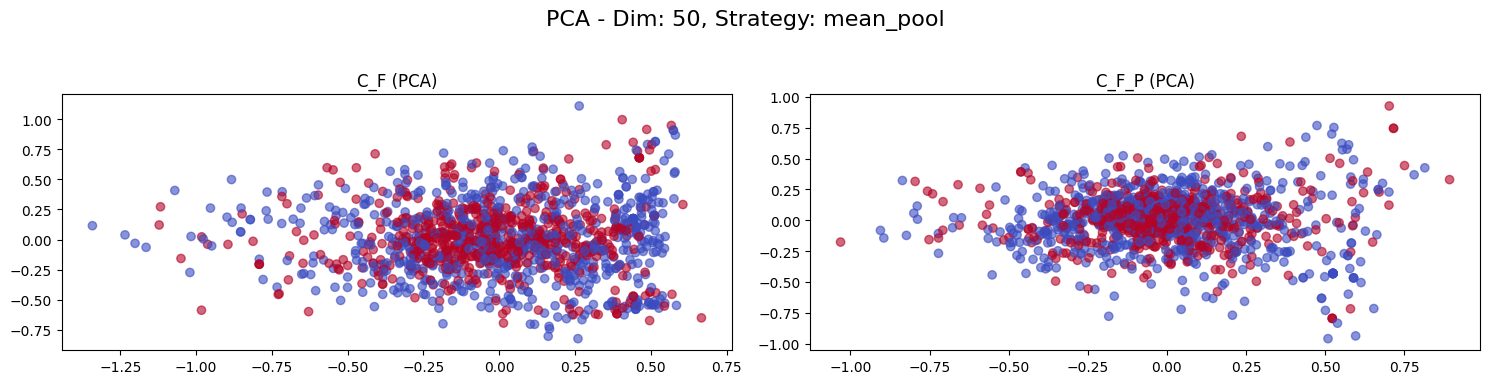


Dim: 50, Strategy: padding
  Category: C_F_P, Shape: (1321, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [500]
  Category: C_F, Shape: (1310, 3), Columns: ['accession_code', 'class', 'embedding']
 Embedding columns: [500]
Processing C_F...
Processing C_F_P...


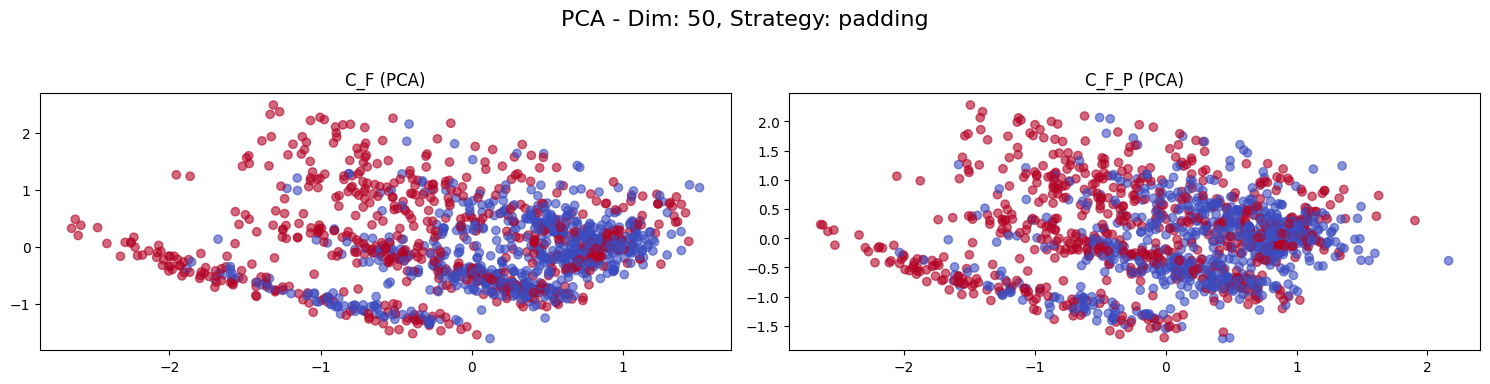

In [50]:
plot_geokg_by_dim(all_dfs_by_dim_strategy, method="PCA")